<a href="https://colab.research.google.com/github/gautamkr1876/AIML_ClassNotes/blob/main/7.%20Advanced%20AI%20Agents/7.%20%20AI%20Modalities%20for%20Video/ai_modality_video.ipynb" target="_blank">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

In [1]:
import os, json
from dotenv import load_dotenv

import textwrap



def pretty_print(*args):
    text = " ".join(str(arg) for arg in args)
    try:
        print(textwrap.fill(text, width=80))
    except Exception as e:
        print(text)  # fallback to normal print if text is not a string

        

load_dotenv('/Users/shivam13juna/Documents/scaler/GEN_AI_REF/openai_key.env')  # reads .env file in the current directory

api_key = os.getenv("OPENAI_API_KEY")

if not api_key:
    raise ValueError(
        "OPENAI_API_KEY not found! "
        "Make sure you have a .env file with: OPENAI_API_KEY=sk-..."
    )

pretty_print("API key loaded successfully.")

API key loaded successfully.


In [4]:
# === SETUP — run me first =================================================
# One-time installs on a fresh machine (uncomment):
# %pip install -q openai opencv-python numpy matplotlib imageio-ffmpeg scikit-video

import os, sys, base64, math, json, subprocess, time
import numpy as np
import cv2
import matplotlib.pyplot as plt

# --- which models to call. Swap freely for the current OpenAI line-up. -----
VISION_MODEL = "gpt-5-nano"               # any vision model: gpt-4o, gpt-4.1, gpt-5-...
EMBED_MODEL  = "text-embedding-3-small"
ASR_MODEL    = "whisper-1"            # the ASR model that returns segment timestamps

# --- illustrative price so we can print dollars. CHECK CURRENT PRICING. -----
PRICE_PER_1M_INPUT_TOKENS = 2.50      # $ per 1M input tokens (gpt-4o-ish; verify!)

# --- OpenAI client. Live calls need OPENAI_API_KEY in your environment. -----
HAVE_KEY = bool(os.environ.get("OPENAI_API_KEY"))
client = None
if HAVE_KEY:
    from openai import OpenAI
    client = OpenAI()                 # reads OPENAI_API_KEY from the environment
    print("OpenAI client ready  ->", VISION_MODEL)
else:
    print("No OPENAI_API_KEY found.")
    print("Non-API cells still run. API cells will print a clear notice and skip.")
    print("To go live:  export OPENAI_API_KEY=sk-...   then restart the kernel.")

# --- the video we'll handle ------------------------------------------------
# DEFAULT: the bundled "Zoom cat lawyer" clip (48s, 1080p, WITH English speech) --
# the frames show a cat, the audio insists "I'm not a cat", so the audio + fusion
# sections (6/8) come alive. Swap in your OWN clip with sound any time.
#VIDEO_PATH = "videos/zoom_cat_lawyer.mp4"
VIDEO_PATH = "videos/bribe.mp4"  # smaller, faster, still has speech

if VIDEO_PATH and os.path.exists(VIDEO_PATH):
    VIDEO_SRC = "bundled 'Zoom cat lawyer' clip (720p, English audio)"
else:
    # Fallback: scikit-video Big Buck Bunny. It HAS an audio track, but it is
    # score/SFX with no speech, so the transcript demo will be thin -- point
    # VIDEO_PATH at a talking clip for the full effect.
    import skvideo.datasets
    VIDEO_PATH = skvideo.datasets.bigbuckbunny()
    VIDEO_SRC  = "scikit-video Big Buck Bunny (no speech)"

print("\nvideo  :", VIDEO_PATH)


OpenAI client ready  -> gpt-5-nano

video  : videos/bribe.mp4


# How to send images to LLM

In [5]:
import base64

vision_response = client.chat.completions.create(
   model="gpt-5-nano",
   messages=[
       {
           "role": "system",
           "content": "You are an art critic who provides gentle feedback for children's illustrations."
       },
       {
           "role": "user",
           "content": [
               {
                   "type": "text",
                   "text": "Analyze this magical  illustration."
               },
               {
                   "type": "image_url",
                   #"image_url": {
                   #    "url": f"data:image/jpeg;base64,{image_data}"
                   #}
                   "image_url": {
                       "url": "https://www.animesenpai.net/wp-content/uploads/2023/12/sef-min.png.webp",
                       "detail": "low" # other options are "medium" and "high", "original"
                   }
               }
           ]
       }
   ],
   #temperature=0.5
)

pretty_print("\n=== Vision Analysis ===")
pretty_print(vision_response.choices[0].message.content)

 === Vision Analysis ===
What a striking, magical illustration. It has a strong mood and a bold
silhouette that pulls you into the scene. Here are some gentle notes you might
consider, whether you’re keeping it as a darker fantasy or tweaking it for a
younger audience.  What works well - Silhouette and pose: The figure stands
large and confident, with diagonal lines that create a sense of motion and
drama. The cape-like extensions and curling tail add dynamism. - Color and
atmosphere: The cool, bluish-gray palette gives a dreamlike, otherworldly feel.
The fog and soft background lights enhance the sense of mystery without being
busy. - Texture and anatomy: The rib-like chest and sculpted musculature read as
magical and ancient, which helps tell a story about power and endurance.  What
could be softened or adjusted (for child-friendly versus more eerie tones) -
Facial features: The head has a jagged, menacing silhouette. For a friendlier
guardian vibe, consider rounder shapes, larger ey

In [6]:
response_vision = client.responses.create(
   model="gpt-5-nano",
   instructions="You are an art critic who provides gentle feedback for children's illustrations.",
   input=[
       {
           "role": "user",
           "content": [
               {
                   "type": "input_text",
                   "text": "Analyze this magical illustration."
               },
               {
                   "type": "input_image",
                   "image_url": "https://www.animesenpai.net/wp-content/uploads/2023/12/sef-min.png.webp",
                   "detail": "original"
               }
           ]
       }
   ]
)

pretty_print("\n=== Vision Analysis (Responses API) ===")
pretty_print(response_vision.output_text)

print("\nInput tokens:", response_vision.usage.input_tokens)
print("Output tokens:", response_vision.usage.output_tokens)
print("Total tokens:", response_vision.usage.total_tokens)

 === Vision Analysis (Responses API) ===
What a striking and atmospheric image. It feels like a doorway to a whisper-
quiet, magical moment. Here are some gentle notes to praise what works and a few
ideas you could try.  What works well - Mood and idea: The creature reads as
powerful, mysterious, and a little ancient—perfect for a magical tale. The foggy
atmosphere amplifies the sense of a hidden world. - Silhouette and design: The
broad shoulders, ribcage motif, and long, tail-like elements create a strong,
dynamic silhouette that reads clearly even at a distance. The horned/crest-like
head shape adds to the fantasy vibe. - Depth and space: The blurred background
lights and hazy fog give depth and help the creature stand out as the focal
point. - Color choice: The cool, desaturated blues/greys feel otherworldly and
consistent with a night-menagerie vibe. The limited palette helps the form read
strongly.  Design and anatomy - The musculature and ribcage are stylized in a
way that’s bol

In [9]:
a = np.arange(1367)
a

array([   0,    1,    2, ..., 1364, 1365, 1366], shape=(1367,))

In [ ]:
400 x 400 x 32 convolve 3 x 3 x 32 x 64 = 398 x 398 x 64

In [11]:
np.linspace(0, 1367, 20, endpoint=False, dtype=int)

array([   0,   68,  136,  205,  273,  341,  410,  478,  546,  615,  683,
        751,  820,  888,  956, 1025, 1093, 1161, 1230, 1298])

# Video

find out for gaming people need 120 fps, but for movies 24 is enough?

In [7]:
# Read metadata WITHOUT decoding every frame (cheap).
cap  = cv2.VideoCapture(VIDEO_PATH)

fps      = cap.get(cv2.CAP_PROP_FPS) or 25.0
n_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))     # may be an estimate (see gotcha)
W        = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
H        = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

cap.release()
duration = n_frames / fps if fps else float("nan")

raw_uint8_gb = n_frames * H * W * 3 / 1e9             # decoded RGB, in memory

print(f"reported shape (T,H,W,C) : ({n_frames}, {H}, {W}, 3)")
print(f"fps / duration           : {fps:.2f} fps  /  {duration:.1f} s")
print(f"raw decoded size (uint8) : {raw_uint8_gb*1000:.1f} MB   "
      f"(the file on disk is far smaller — that's compression)")



reported shape (T,H,W,C) : (1367, 1080, 1920, 3)
fps / duration           : 23.81 fps  /  57.4 s
raw decoded size (uint8) : 8503.8 MB   (the file on disk is far smaller — that's compression)


<!--Hx264, hx265-->

In [8]:
100

100/8

12.5

In [ ]:
0, 13, 26, 39, 52, 65, 78, 91

In [12]:
def extract_frames(path, num_frames=8, size=512):
    """Decode `path` -> `num_frames` uniformly sampled RGB frames + timestamps.

    WHY uniform sampling: consecutive frames are near-duplicates (we prove this
    in section 2), so decoding densely wastes CPU and, downstream, tokens/$. We
    take a few evenly-spaced frames and REMEMBER WHEN each was taken, because
    the model cannot infer time on its own — we have to tell it (section 3).

    Returns (frames, stamps): frames = list of HxWx3 uint8 RGB; stamps = seconds.
    """
    cap = cv2.VideoCapture(path)
    fps = cap.get(cv2.CAP_PROP_FPS) or 25.0
    frames_all, stamps_all, i = [], [], 0
    # Decode SEQUENTIALLY . We shrink each frame as we read
    # it, so memory stays bounded even for a minute of footage.
    while True:
        ok, bgr = cap.read()
        if not ok:
            break
        rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)     # GOTCHA: OpenCV is BGR!
        h, w = rgb.shape[:2]
        s = min(1.0, size / max(h, w))                 # shrink only, never upscale
        if s < 1.0:
            rgb = cv2.resize(rgb, (int(w * s), int(h * s)))
        frames_all.append(rgb)
        stamps_all.append(i / fps)
        i += 1
    cap.release()
    if not frames_all:
        raise RuntimeError("Decoded 0 frames. Bad codec/path?")
    sel = np.linspace(0, len(frames_all) - 1, num_frames).round().astype(int)
    return [frames_all[k] for k in sel], [stamps_all[k] for k in sel]


def frame_to_data_url(rgb, quality=80):
    """RGB frame -> base64 JPEG data URL (what the chat API expects).

    JPEG, not PNG: you upload these over the wire, and JPEG is ~10x smaller for
    photographic frames. quality=80 is invisible to a VLM but halves the bytes.
    """
    bgr = cv2.cvtColor(rgb, cv2.COLOR_RGB2BGR)         # imencode wants BGR back
    ok, buf = cv2.imencode(".jpg", bgr, [cv2.IMWRITE_JPEG_QUALITY, quality])
    return "data:image/jpeg;base64," + base64.b64encode(buf).decode("ascii")


# Sample 8 frames once; we reuse these throughout.
frames, stamps = extract_frames(VIDEO_PATH, num_frames=8, size=512)
print(f"sampled {len(frames)} frames at t = {[round(t,1) for t in stamps]} s")
print(f"each frame shape (after resize): {frames[0].shape}")

sampled 8 frames at t = [0.0, 8.2, 16.4, 24.6, 32.8, 41.0, 49.2, 57.4] s
each frame shape (after resize): (288, 512, 3)


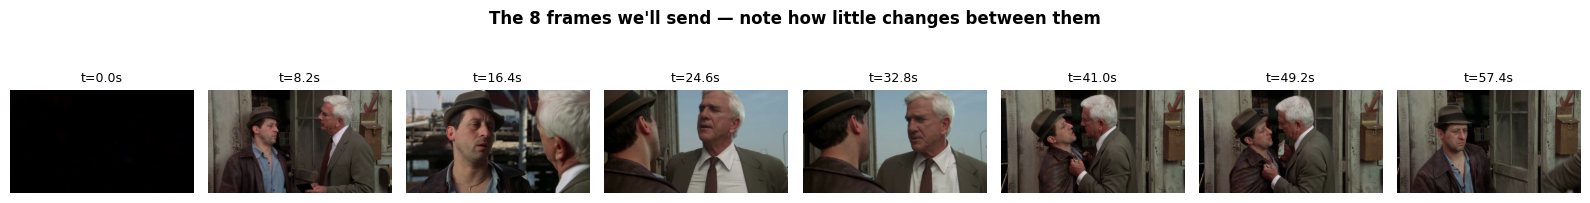

In [13]:
# --- look at the frames the model will actually receive --------------------
fig, ax = plt.subplots(1, len(frames), figsize=(2.0 * len(frames), 2.4))
for a, f, t in zip(ax, frames, stamps):
    a.imshow(f); a.set_title(f"t={t:.1f}s", fontsize=9); a.axis("off")
fig.suptitle("The 8 frames we'll send — note how little changes between them",
             fontweight="bold")
fig.tight_layout(); plt.show()

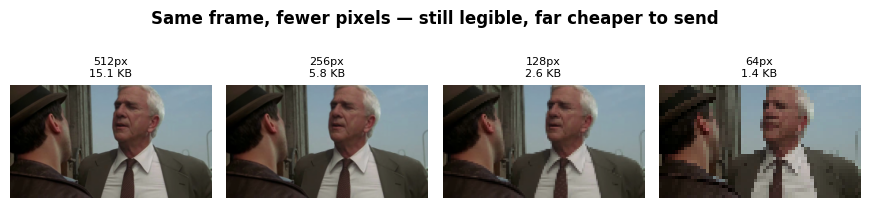

raw decoded clip : 1367 frames x 1080x1920  =   8503.8 MB
what you send    : 8 frames x 288x512  =    3.54 MB   (2403x smaller)


In [14]:
base = frames[3]
widths = [base.shape[1], 256, 128, 64]
fig, ax = plt.subplots(1, len(widths), figsize=(2.2 * len(widths), 2.4))
for a, w in zip(ax, widths):
    sc = w / base.shape[1]
    thumb = cv2.resize(base, (w, max(1, int(base.shape[0] * sc))))
    kb = len(cv2.imencode(".jpg", cv2.cvtColor(thumb, cv2.COLOR_RGB2BGR),
                          [cv2.IMWRITE_JPEG_QUALITY, 80])[1]) / 1024
    a.imshow(thumb); a.axis("off"); a.set_title(f"{w}px\n{kb:.1f} KB", fontsize=8)
fig.suptitle("Same frame, fewer pixels — still legible, far cheaper to send",
             fontweight="bold")
fig.tight_layout(); plt.show()

# Sampling and resizing COMPOUND. Raw decoded clip vs what you actually send:
raw_mb  = n_frames * H * W * 3 / 1e6
sent_mb = len(frames) * frames[0].shape[0] * frames[0].shape[1] * 3 / 1e6
print(f"raw decoded clip : {n_frames} frames x {H}x{W}  = {raw_mb:8.1f} MB")
print(f"what you send    : {len(frames)} frames x "
      f"{frames[0].shape[0]}x{frames[0].shape[1]}  = {sent_mb:7.2f} MB"
      f"   ({raw_mb / max(sent_mb, 1e-9):.0f}x smaller)")

In [15]:
a = np.array([2, 5, 10, 15])

np.diff(a, axis=0)

array([3, 5, 5])

decoded 1367 frames at 64x64 just to measure change
mean consecutive-frame difference : 3.52  (0 = identical)


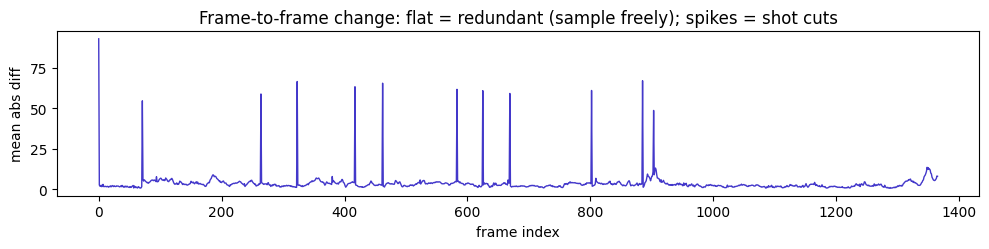

In [16]:
# --- measure temporal redundancy + find shot cuts (cheap, no model) --------
# Decode densely at TINY resolution: we only need a change signal, not detail.
# Decode the entire video at low resolution (64x64) to measure frame-to-frame change.
# This is cheap: we only need a signal, not detail. We'll use this to find shot cuts
# and understand temporal redundancy (why sampling works).
import array


cap, small = cv2.VideoCapture(VIDEO_PATH), []
fps_dense = cap.get(cv2.CAP_PROP_FPS) or 25.0
while True:
    ok, bgr = cap.read()
    if not ok:
        break
    # Convert BGR (OpenCV default) to grayscale for change detection.
    small.append(cv2.cvtColor(cv2.resize(bgr, (64, 64)), cv2.COLOR_BGR2GRAY))
cap.release()
# Convert list of grayscale frames to float32 array: (T, 64, 64).
small = np.asarray(small, np.float32)

# Mean absolute difference between consecutive frames.
#   low   = near-duplicate -> sampling is safe; dense frames waste tokens
#   SPIKE = scene/shot cut  -> a natural chunk boundary for long video (sec 7/8)
#a = np.array([2, 5, 10, 15])

#np.diff(a, axis=0)

mad = np.abs(np.diff(small, axis=0)).mean(axis=(1, 2))

print(f"decoded {len(small)} frames at 64x64 just to measure change")
print(f"mean consecutive-frame difference : {mad.mean():.2f}  (0 = identical)")

plt.figure(figsize=(10, 2.6))
plt.plot(mad, lw=1, color="#4338ca")

plt.title("Frame-to-frame change: flat = redundant (sample freely); spikes = shot cuts")
plt.xlabel("frame index"); plt.ylabel("mean abs diff"); plt.tight_layout(); plt.show()


In [17]:
for frame, stamp in zip(frames, stamps):
    data_url = frame_to_data_url(frame, quality=80)
    print(f"t={stamp:.1f}s  ->  {len(data_url)/1024:.1f} KB")

t=0.0s  ->  4.3 KB
t=8.2s  ->  27.6 KB
t=16.4s  ->  26.5 KB
t=24.6s  ->  20.2 KB
t=32.8s  ->  19.5 KB
t=41.0s  ->  31.0 KB
t=49.2s  ->  31.7 KB
t=57.4s  ->  28.6 KB


# Sending Frames

[{'type': 'text',
  'text': 'These are frames sampled IN ORDER from one short video; each is labeled with its timestamp. Reason about what happens over time.'},
 {'type': 'text', 'text': '[frame @ 0.0s]'},
 {'type': 'image_url',
  'image_url': {'url': '',
   'detail': 'low'}},
 {'type': 'text', 'text': '[frame @ 8.2s]'},
 {'type': 'image_url',
  'image_url': {'url': '',
   'detail': 'low'}},
 {'type': 'text', 'text': '[frame @ 16.4s]'},
 {'type': 'image_url',
  'image_url': {'url': '',
   'detail': 'low'}},
 {'type': 'text', 'text': '[frame @ 24.6s]'},
 {'type': 'image_url',
  'image_url': {'url': '',
   'detail': 'low'}},
 {'type': 'text', 'text': '[frame @ 32.8s]'},
 {'type': 'image_url',
  'image_url': {'url': '',
   'detail': 'low'}},
 {'type': 'text', 'text': '[frame @ 41.0s]'},
 {'type': 'image_url',
  'image_url': {'url': '',
   'detail': 'low'}},
 {'type': 'text', 'text': '[frame @ 49.2s]'},
 {'type': 'image_url',
  'image_url': {'url': '',
   'detail': 'low'}},
 {'type': 'text
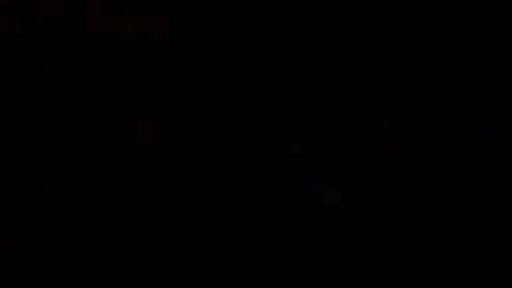
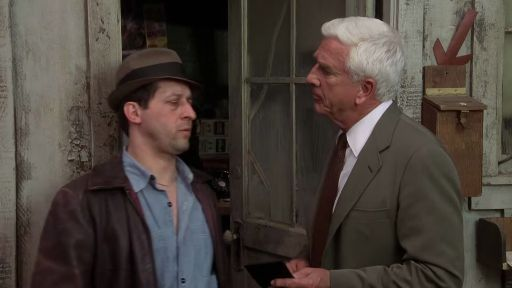
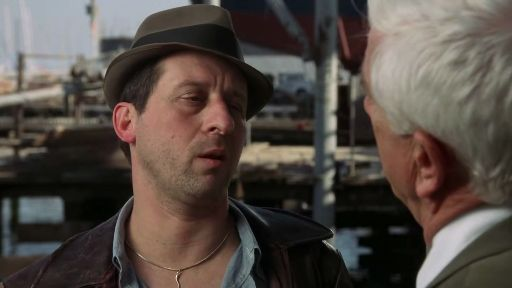
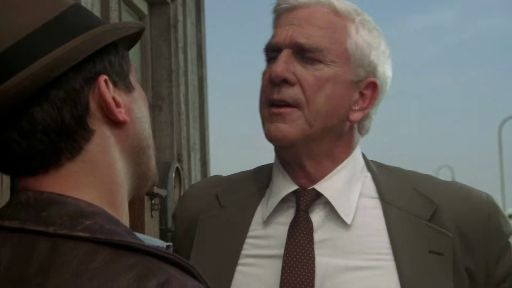
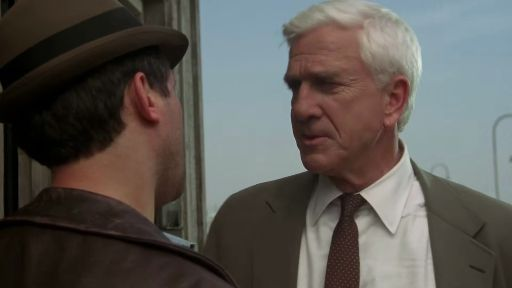
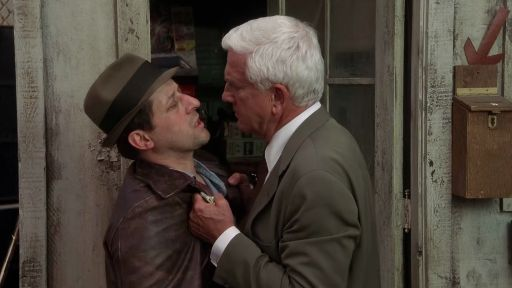
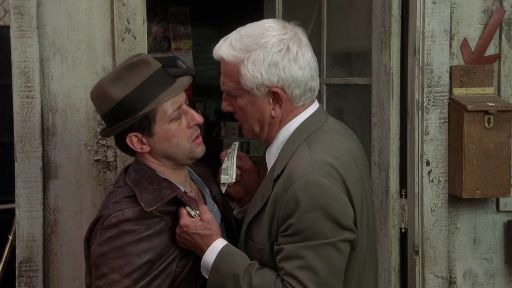
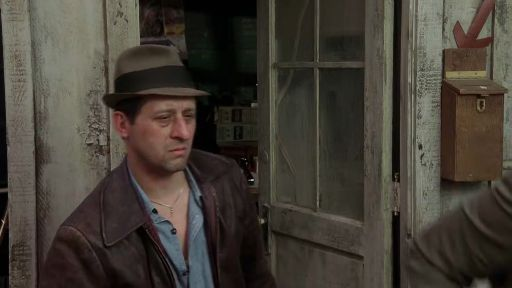

In [18]:
content = [{
    "type": "text",
    "text": ("These are frames sampled IN ORDER from one short video; each is "
             "labeled with its timestamp. Reason about what happens over time.")
}]

for t, f in zip(stamps, frames):
    content.append({"type": "text", "text": f"[frame @ {t:.1f}s]"})        # order + time
    content.append({"type": "image_url",
                    "image_url": {"url": frame_to_data_url(f), "detail": "low"}})

content.append({"type": "text",
                "text": "In 2-3 sentences, describe what happens across the clip."})

content


In [21]:

resp = client.chat.completions.create(
        model=VISION_MODEL, 
        messages=[{"role": "user", "content": content}])
pretty_print(resp.choices[0].message.content)
 
pretty_print("\n[usage]", resp.usage) 

Two men stand outside a doorway and begin with a tense conversation. The
exchange escalates into a physical confrontation, with the older man forcing the
younger man to the door and grabbing him by the jacket/collar, ending still in a
close, charged standoff.
 [usage] CompletionUsage(completion_tokens=1346, prompt_tokens=1844,
total_tokens=3190,
completion_tokens_details=CompletionTokensDetails(accepted_prediction_tokens=0,
audio_tokens=0, reasoning_tokens=1280, rejected_prediction_tokens=0),
prompt_tokens_details=PromptTokensDetails(audio_tokens=0, cached_tokens=1152))


# Audio

In [24]:
# --- extract the audio track to 16kHz mono WAV via the bundled ffmpeg -------
import imageio_ffmpeg
FFMPEG = imageio_ffmpeg.get_ffmpeg_exe()       # path to a bundled ffmpeg binary
AUDIO_PATH = "clip_audio.wav"

# -vn drops video; pcm WAV is universally supported (no codec-availability risk).
proc = subprocess.run(
    [FFMPEG, "-y", "-i", VIDEO_PATH, "-vn", "-ac", "1", "-ar", "16000", AUDIO_PATH],
    capture_output=True, text=True)

# If the clip has no audio stream, ffmpeg writes nothing useful -> detect that.
HAS_AUDIO = os.path.exists(AUDIO_PATH) and os.path.getsize(AUDIO_PATH) > 2000
if HAS_AUDIO:
    print(f"extracted audio -> {AUDIO_PATH} "
          f"({os.path.getsize(AUDIO_PATH)/1e6:.2f} MB, 16kHz mono)")
else:
    print("This clip has NO audio stream in it.")
    print("Set VIDEO_PATH to a short clip WITH SOUND to run the transcript demo.")

extracted audio -> clip_audio.wav (1.84 MB, 16kHz mono)


In [25]:
segments = []   

with open(AUDIO_PATH, "rb") as fh:
        tr = client.audio.transcriptions.create(
            model=ASR_MODEL, file=fh,
            response_format="verbose_json",          # <- needed for timestamps
            timestamp_granularities=["segment"])
    # The SDK returns objects; normalize to plain dicts so the rest stays simple.
def field(o, k):
    return o.get(k) if isinstance(o, dict) else getattr(o, k, None)
for s in tr.segments:
    segments.append({"start": field(s, "start"), "end": field(s, "end"),
                        "text": (field(s, "text") or "").strip()})
print(f"{len(segments)} transcript segments. First few:")
for s in segments:
    print(f"  [{s['start']:5.1f}-{s['end']:5.1f}s] {s['text']}")

49 transcript segments. First few:
  [  0.0-  1.0s] Lieutenant Drebin, police squad.
  [  1.0-  2.0s] Oh, I remember you, Drebin.
  [  2.0-  3.0s] What do you want?
  [  3.0-  4.0s] I want to ask you some questions.
  [  4.0-  5.0s] You familiar with that face?
  [  5.0-  6.0s] I don't know.
  [  6.0-  7.0s] My memory ain't so great.
  [  7.0-  8.0s] Oh, yeah?
  [  8.0-  9.0s] Maybe this will refresh your memory.
  [  9.0- 10.0s] I don't know.
  [ 10.0- 11.0s] It's still kind of hazy.
  [ 11.0- 12.0s] How about this?
  [ 12.0- 13.0s] Yeah, I remember him.
  [ 13.0- 14.0s] I used to see him around.
  [ 14.0- 15.0s] Why do you want to know?
  [ 15.0- 16.0s] I can't tell you that.
  [ 16.0- 17.0s] Well, maybe this will help.
  [ 17.0- 18.0s] I really don't think I should.
  [ 18.0- 19.0s] Yeah?
  [ 19.0- 20.0s] I don't think I should.
  [ 20.0- 21.0s] I don't think I should.
  [ 21.0- 22.0s] I don't think I should.
  [ 22.0- 23.0s] I don't think I should.
  [ 23.0- 24.0s] I don't think I 

In [26]:
transcript_block = "\n".join(
    f"[{s['start']:.1f}-{s['end']:.1f}s] {s['text']}" for s in segments)
transcript_block


"[0.0-1.0s] Lieutenant Drebin, police squad.\n[1.0-2.0s] Oh, I remember you, Drebin.\n[2.0-3.0s] What do you want?\n[3.0-4.0s] I want to ask you some questions.\n[4.0-5.0s] You familiar with that face?\n[5.0-6.0s] I don't know.\n[6.0-7.0s] My memory ain't so great.\n[7.0-8.0s] Oh, yeah?\n[8.0-9.0s] Maybe this will refresh your memory.\n[9.0-10.0s] I don't know.\n[10.0-11.0s] It's still kind of hazy.\n[11.0-12.0s] How about this?\n[12.0-13.0s] Yeah, I remember him.\n[13.0-14.0s] I used to see him around.\n[14.0-15.0s] Why do you want to know?\n[15.0-16.0s] I can't tell you that.\n[16.0-17.0s] Well, maybe this will help.\n[17.0-18.0s] I really don't think I should.\n[18.0-19.0s] Yeah?\n[19.0-20.0s] I don't think I should.\n[20.0-21.0s] I don't think I should.\n[21.0-22.0s] I don't think I should.\n[22.0-23.0s] I don't think I should.\n[23.0-24.0s] I don't think I should.\n[24.0-25.0s] I don't think I should.\n[25.0-26.0s] I don't think I should.\n[27.0-28.0s] I really don't think I shoul

In [33]:

fused = [{"type": "text",
            "text": "TRANSCRIPT (timestamped):\n" + transcript_block +
                    "\n\nBelow are a few keyframes for visual context."}]
for t, f in zip(stamps, frames):         # just 4 keyframes, low detail
    fused.append({"type": "text", "text": f"[frame @ {t:.1f}s]"})
    fused.append({"type": "image_url",
                    "image_url": {"url": frame_to_data_url(f), "detail": "low"}})
fused.append({"type": "text",
                "text": "Summarize the clip in 3 bullets, each citing a timestamp."})

resp = client.chat.completions.create(
        model=VISION_MODEL, 
        messages=[{"role": "user", "content": fused}])
pretty_print(resp.choices[0].message.content)            
        

    

- 0.0–5.0s: Drebin begins the interrogation, asking Nordberg about a familiar
face while Nordberg downplays his memory.  - 31.0–36.0s: Nordberg admits
something about the other man and Drebin calls him out, revealing the accusation
that Nordberg “was dirty” and involved in dealing H.  - 46.0–50.0s: Nordberg
offers a bribe, and Drebin presses him, leading to the plan to visit Ludwig’s
office and dig for answers.


[{'type': 'text',
  'text': "TRANSCRIPT (timestamped):\n[0.0-1.0s] Lieutenant Drebin, police squad.\n[1.0-2.0s] Oh, I remember you, Drebin.\n[2.0-3.0s] What do you want?\n[3.0-4.0s] I want to ask you some questions.\n[4.0-5.0s] You familiar with that face?\n[5.0-6.0s] I don't know.\n[6.0-7.0s] My memory ain't so great.\n[7.0-8.0s] Oh, yeah?\n[8.0-9.0s] Maybe this will refresh your memory.\n[9.0-10.0s] I don't know.\n[10.0-11.0s] It's still kind of hazy.\n[11.0-12.0s] How about this?\n[12.0-13.0s] Yeah, I remember him.\n[13.0-14.0s] I used to see him around.\n[14.0-15.0s] Why do you want to know?\n[15.0-16.0s] I can't tell you that.\n[16.0-17.0s] Well, maybe this will help.\n[17.0-18.0s] I really don't think I should.\n[18.0-19.0s] Yeah?\n[19.0-20.0s] I don't think I should.\n[20.0-21.0s] I don't think I should.\n[21.0-22.0s] I don't think I should.\n[22.0-23.0s] I don't think I should.\n[23.0-24.0s] I don't think I should.\n[24.0-25.0s] I don't think I should.\n[25.0-26.0s] I don't thi
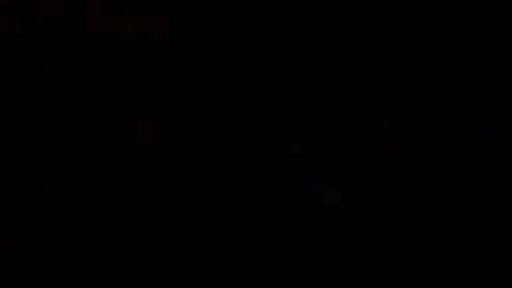
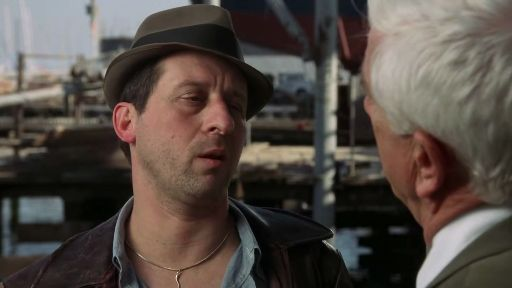
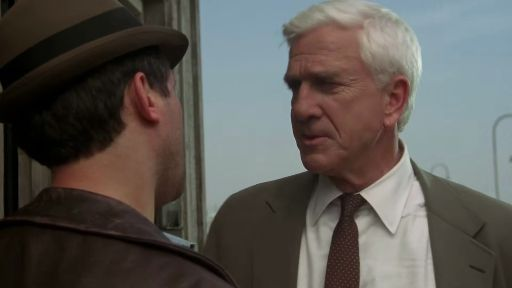
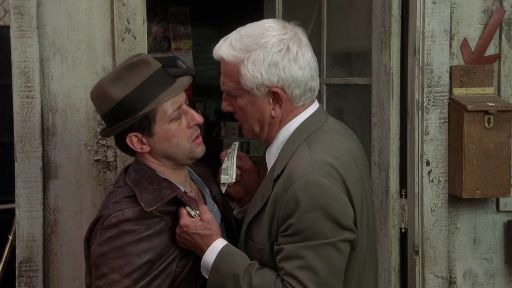

In [32]:
fused

In [30]:
pretty_print(transcript_block)

[0.0-1.0s] Lieutenant Drebin, police squad. [1.0-2.0s] Oh, I remember you,
Drebin. [2.0-3.0s] What do you want? [3.0-4.0s] I want to ask you some
questions. [4.0-5.0s] You familiar with that face? [5.0-6.0s] I don't know.
[6.0-7.0s] My memory ain't so great. [7.0-8.0s] Oh, yeah? [8.0-9.0s] Maybe this
will refresh your memory. [9.0-10.0s] I don't know. [10.0-11.0s] It's still kind
of hazy. [11.0-12.0s] How about this? [12.0-13.0s] Yeah, I remember him.
[13.0-14.0s] I used to see him around. [14.0-15.0s] Why do you want to know?
[15.0-16.0s] I can't tell you that. [16.0-17.0s] Well, maybe this will help.
[17.0-18.0s] I really don't think I should. [18.0-19.0s] Yeah? [19.0-20.0s] I
don't think I should. [20.0-21.0s] I don't think I should. [21.0-22.0s] I don't
think I should. [22.0-23.0s] I don't think I should. [23.0-24.0s] I don't think
I should. [24.0-25.0s] I don't think I should. [25.0-26.0s] I don't think I
should. [27.0-28.0s] I really don't think I should. [28.0-29.0s] Yeah?
[29.0

In [31]:
for t, f in zip(stamps[::2], frames[::2]):
    print(f"[frame @ {t:.1f}s]  ->  {len(frame_to_data_url(f))/1024:.1f} KB")

[frame @ 0.0s]  ->  4.3 KB
[frame @ 16.4s]  ->  26.5 KB
[frame @ 32.8s]  ->  19.5 KB
[frame @ 49.2s]  ->  31.7 KB


In [ ]:

fused = [{"type": "text",
            "text": "TRANSCRIPT (timestamped):\n" + transcript_block +
                    "\n\nBelow are a few keyframes for visual context."}]
for t, f in zip(stamps[::2], frames[::2]):         # just 4 keyframes, low detail
    fused.append({"type": "text", "text": f"[frame @ {t:.1f}s]"})
    fused.append({"type": "image_url",
                    "image_url": {"url": frame_to_data_url(f), "detail": "low"}})
fused.append({"type": "text",
                "text": "What movie it is coming from?"})

resp = client.chat.completions.create(
        model=VISION_MODEL, 
        messages=[{"role": "user", "content": fused}])
pretty_print(resp.choices[0].message.content)            
        

    

The Naked Gun 2½: The Smell of Fear (1991).   Reason: The transcript references
Lieutenant Drebin, Nordberg, and Ludwig’s Shipping—elements and lines from that
sequel’s interrogation scenes.
